# Shrunk $\pi$: Phase 3A mechanism audit

This versioned lab notebook reads and validates immutable Plan 11 Phase 2 and Phase 3 artifacts only. Every analysis below is post hoc and exploratory. It does not alter Phase 3 inference, select a new endpoint, or execute learner compute. Positive NLL gain means fixed NLL minus blend NLL, so positive values favor the blend.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'mnist_experiment/plan11.md').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Run this notebook from within the repository')
sys.path.insert(0, str(ROOT))
from mnist_experiment.rotated_mnist.plan11.mechanism_audit import load_mechanism_audit

audit = load_mechanism_audit(ROOT)
colors = {'fixed': '#40566b', 'blend': '#c45a3c', 'gain': '#147d75', 'accent': '#d1a22b'}
plt.rcParams.update({'figure.dpi': 115, 'axes.titlesize': 11, 'axes.labelsize': 9, 'font.size': 9})

/home/evan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Integrity and provenance

No result is returned until the frozen ledgers and every required completed-file hash pass validation. The analysis source hash records the exact implementation used by this notebook.

In [2]:
contract = audit['analysis_contract']
provenance_rows = []
for phase, item in audit['provenance'].items():
    provenance_rows.append({
        'evidence': phase,
        'study hash': item['study_hash'],
        'validated trajectories': item['validated_trajectory_count'],
        'validated assets': item['validated_asset_count'],
    })
display(pd.DataFrame(provenance_rows).set_index('evidence'))
display(Markdown(f"**Analysis contract:** `{contract['phase']}`  \n**Source SHA-256:** `{contract['analysis_source_sha256']}`  \n**Training or mutation:** `{contract['trains_or_mutates']}`"))

,study hash,validated trajectories,validated assets
evidence,,,
development,12b1ff1dbf3d0abdf4534cceaaacf738ab658de59d0828...,300,12
phase3,ffe20551118e39a405f02f31caa2765fc7075b6a116c78...,1408,352


**Analysis contract:** `plan11_phase3a_mechanism_audit_v1`  
**Source SHA-256:** `ccd555eec5c81ca665046abfa81325827bbb50ab9d35a5e584bb7499dfe90461`  
**Training or mutation:** `False`

## Confirmation and reversal

The fixed-size Phase 3 result remains the inferential result. Development is shown only to document selection and winner's curse.

In [3]:
confirmation = []
for schedule, result in audit['schedules'].items():
    value = result['primary']
    confirmation.append({
        'schedule': schedule, 'mean gain': value['mean'],
        '95% low': value['confidence_low'], '95% high': value['confidence_high'],
        'two-sided p': value['two_sided_p'],
        'positive replicas': f"{value['positive_count']}/{value['count']}",
    })
display(pd.DataFrame(confirmation).set_index('schedule').style.format({
    'mean gain': '{:+.5f}', '95% low': '{:+.5f}', '95% high': '{:+.5f}', 'two-sided p': '{:.5f}'
}))
reversal = []
for row in audit['development_to_confirmation']:
    reversal.append({
        'schedule': row['schedule'],
        'development mean': row['development']['mean'],
        'development wins': f"{row['development']['positive_count']}/12",
        'confirmation mean': row['confirmation']['mean'],
        'confirmation wins': f"{row['confirmation']['positive_count']}/352",
        'mean change': row['mean_change'],
    })
display(pd.DataFrame(reversal).set_index('schedule').style.format({
    'development mean': '{:+.5f}', 'confirmation mean': '{:+.5f}', 'mean change': '{:+.5f}'
}).set_caption('Development-to-confirmation reversal'))

,mean gain,95% low,95% high,two-sided p,positive replicas
schedule,,,,,
linear,-0.06207,-0.12382,-0.00032,0.04884,152/352
sigmoid,-0.01966,-0.09035,+0.05104,0.58487,171/352


,development mean,development wins,confirmation mean,confirmation wins,mean change
schedule,,,,,
linear,+0.13709,6/12,-0.06207,152/352,-0.19916
sigmoid,+0.03572,8/12,-0.01966,171/352,-0.05538


## Exposure-indexed predictive effects

Running AUC is the integral of these earlier differences, not independent evidence. Vertical rules mark traversal boundaries.

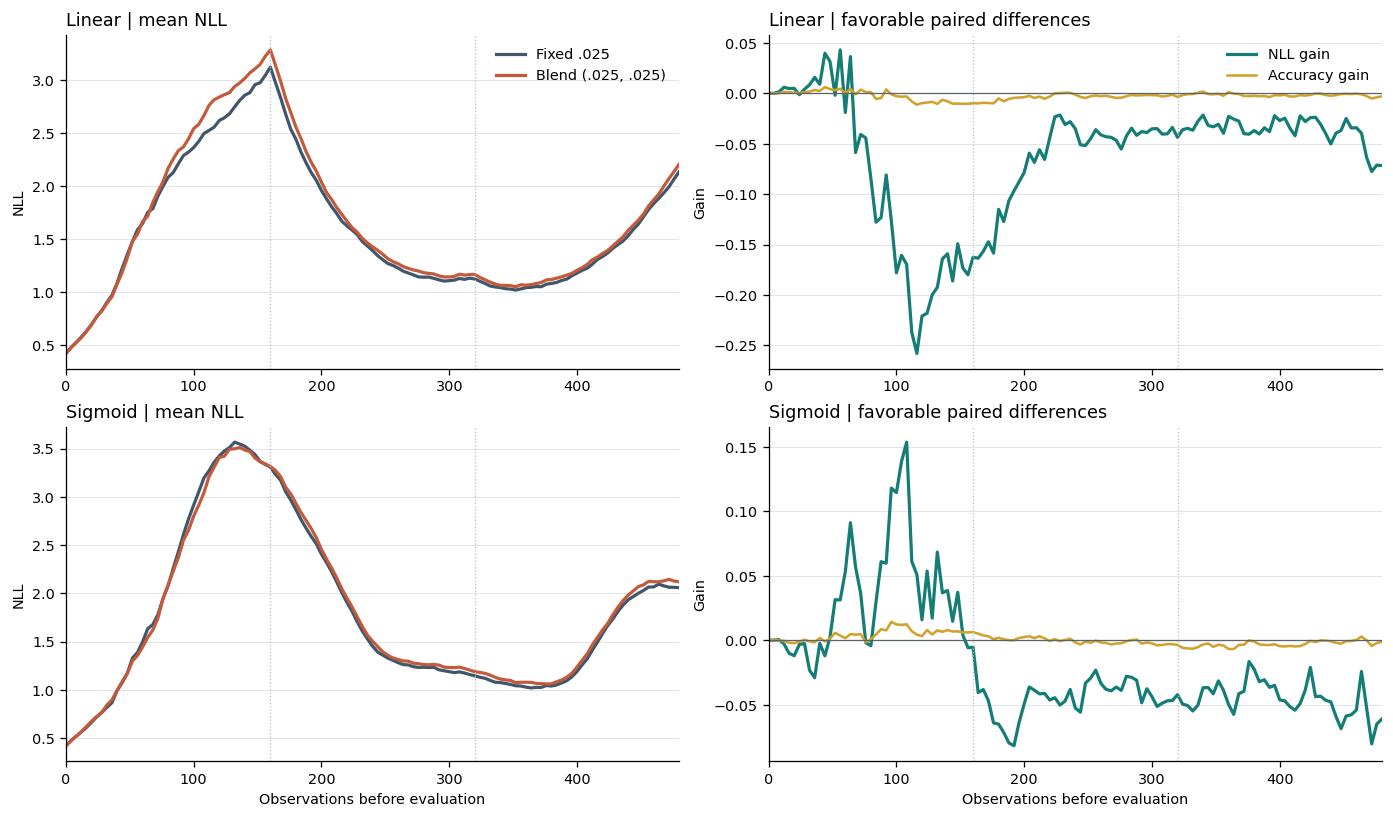

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout='constrained')
for row_index, (schedule, result) in enumerate(audit['schedules'].items()):
    x = np.asarray(result['exposure'])
    fixed_nll = np.asarray(result['predictive_means']['fixed']['current_nll'])
    blend_nll = np.asarray(result['predictive_means']['blend']['current_nll'])
    fixed_acc = np.asarray(result['predictive_means']['fixed']['current_environment_accuracy'])
    blend_acc = np.asarray(result['predictive_means']['blend']['current_environment_accuracy'])
    ax = axes[row_index, 0]
    ax.plot(x, fixed_nll, color=colors['fixed'], lw=2, label='Fixed .025')
    ax.plot(x, blend_nll, color=colors['blend'], lw=2, label='Blend (.025, .025)')
    ax.set_title(f'{schedule.capitalize()} | mean NLL', loc='left')
    ax.set_ylabel('NLL')
    gain_ax = axes[row_index, 1]
    gain_ax.plot(x, fixed_nll - blend_nll, color=colors['gain'], lw=2, label='NLL gain')
    gain_ax.plot(x, blend_acc - fixed_acc, color=colors['accent'], lw=1.6, label='Accuracy gain')
    gain_ax.axhline(0, color='#59636c', lw=.8)
    gain_ax.set_title(f'{schedule.capitalize()} | favorable paired differences', loc='left')
    gain_ax.set_ylabel('Gain')
    for target in (ax, gain_ax):
        for boundary in (160, 320):
            target.axvline(boundary, color='#b7bec4', lw=.8, ls=':')
        target.grid(axis='y', color='#e0e4e7', lw=.6)
        target.spines[['top', 'right']].set_visible(False)
        target.set_xlim(0, 480)
        if row_index == 1:
            target.set_xlabel('Observations before evaluation')
axes[0, 0].legend(frameon=False)
axes[0, 1].legend(frameon=False)
plt.show()

## Calibration, digit groups, and classes

All subgroup and class summaries are descriptive. No class is promoted to a confirmatory endpoint. Positive values favor the blend; recall gains use blend minus fixed.

schedule,linear,sigmoid
metric,,
accuracy_gain,-0.00258,+0.00027
brier_gain,-0.00623,-0.00123
calibration_gain,-0.00417,-0.00229
nine_nll_gain,+0.00858,-0.09271
nine_recall_gain,-0.00120,-0.00070
non_nine_nll_gain,-0.07000,-0.01146


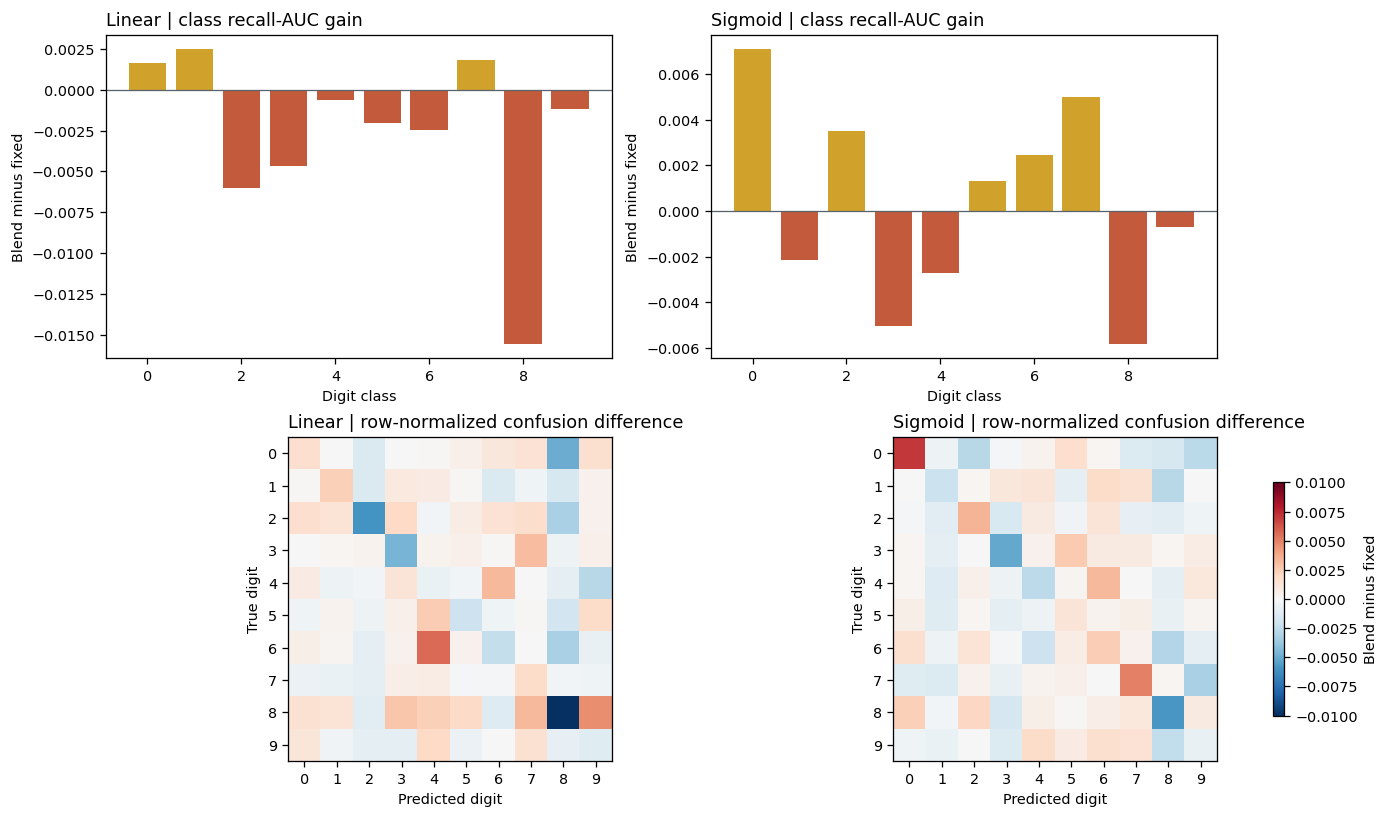

In [5]:
secondary_rows = []
for schedule, result in audit['schedules'].items():
    for metric, value in result['secondary'].items():
        secondary_rows.append({'schedule': schedule, 'metric': metric, 'mean': value['mean'], '95% low': value['confidence_low'], '95% high': value['confidence_high']})
secondary_frame = pd.DataFrame(secondary_rows)
display(secondary_frame.pivot(index='metric', columns='schedule', values='mean').style.format('{:+.5f}').set_caption('Exploratory whole-path mean gains'))

fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout='constrained')
for column, (schedule, result) in enumerate(audit['schedules'].items()):
    classes = pd.DataFrame(result['class_recall'])
    axes[0, column].bar(classes['class'], classes['mean'], color=[colors['accent'] if value >= 0 else colors['blend'] for value in classes['mean']])
    axes[0, column].axhline(0, color='#59636c', lw=.8)
    axes[0, column].set_title(f'{schedule.capitalize()} | class recall-AUC gain', loc='left')
    axes[0, column].set_xlabel('Digit class')
    axes[0, column].set_ylabel('Blend minus fixed')
    image = axes[1, column].imshow(np.asarray(result['confusion_difference']), cmap='RdBu_r', vmin=-.01, vmax=.01, aspect='equal')
    axes[1, column].set_title(f'{schedule.capitalize()} | row-normalized confusion difference', loc='left')
    axes[1, column].set_xlabel('Predicted digit')
    axes[1, column].set_ylabel('True digit')
    axes[1, column].set_xticks(range(10))
    axes[1, column].set_yticks(range(10))
fig.colorbar(image, ax=axes[1, :], shrink=.72, label='Blend minus fixed')
plt.show()

## Coupled policy mechanics

The one realized action jointly changes EWC strength, direct Fisher refresh, $q_t$, and future recommendations. These plots describe the coupled path and cannot identify one channel as causal.

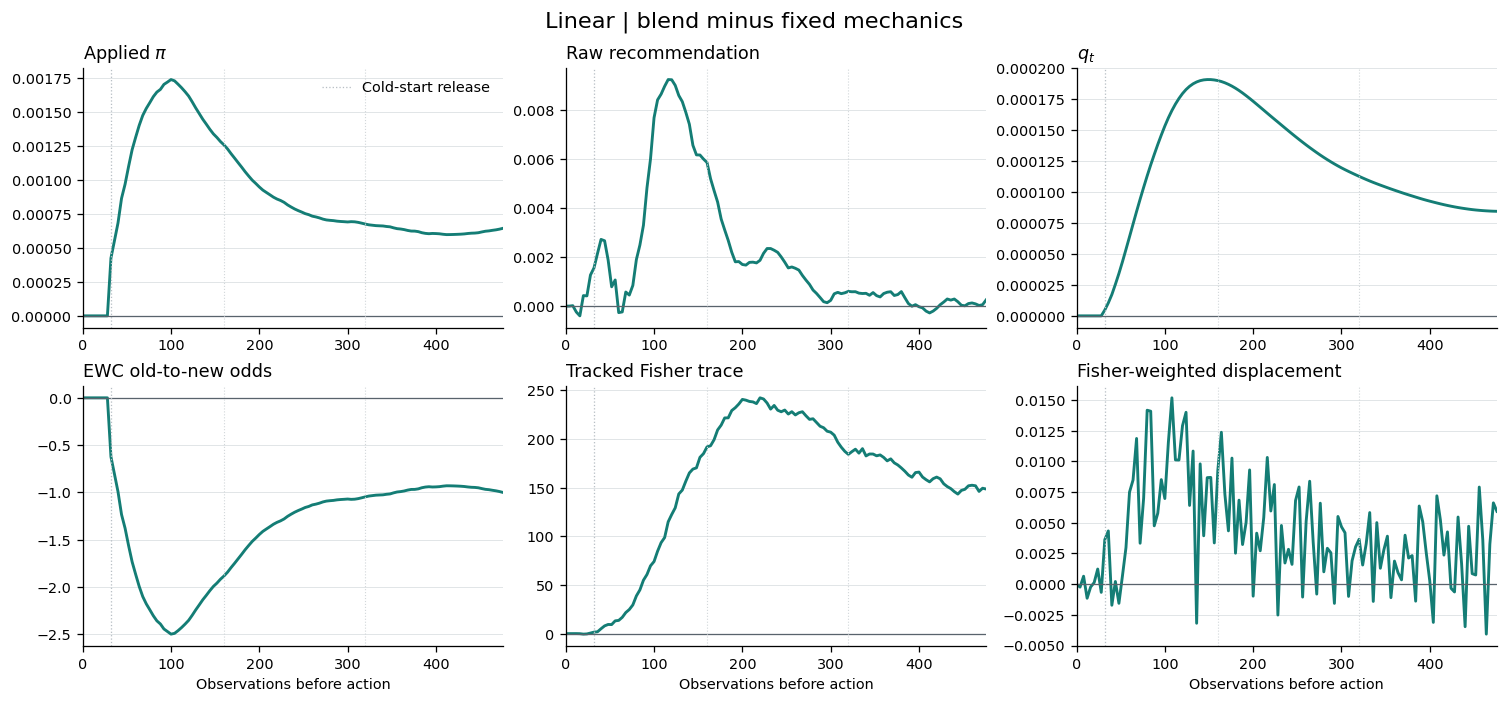

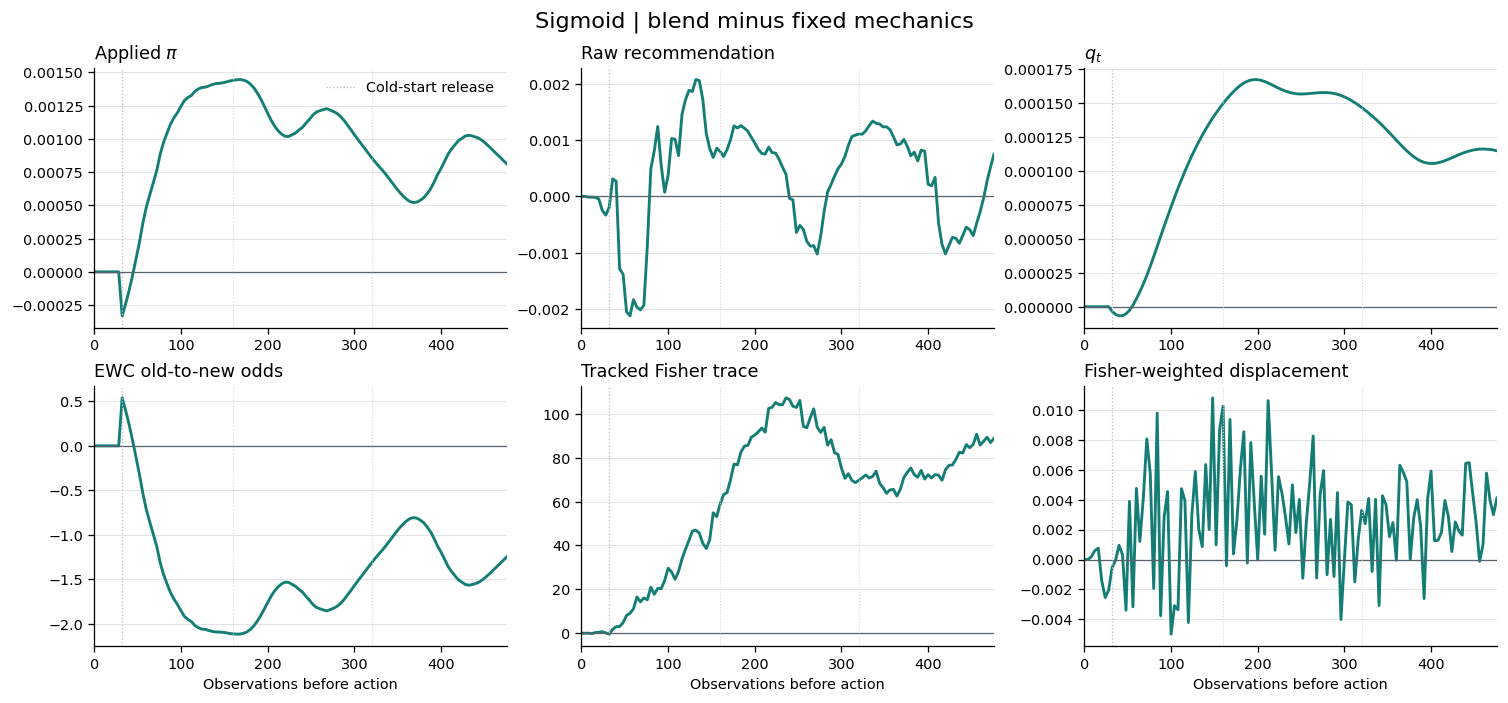

In [6]:
mechanics = [
    ('applied_pi', r'Applied $\pi$', 1.0),
    ('recommendation_pi', 'Raw recommendation', 1.0),
    ('q', '$q_t$', 1.0),
    ('ewc_odds', 'EWC old-to-new odds', 1.0),
    ('previous_fisher_trace', 'Tracked Fisher trace', 1.0),
    ('fisher_displacement_norm', 'Fisher-weighted displacement', 1.0),
]
for schedule, result in audit['schedules'].items():
    x = np.asarray(result['exposure'][:-1])
    fig, axes = plt.subplots(2, 3, figsize=(13, 6), layout='constrained')
    fig.suptitle(f'{schedule.capitalize()} | blend minus fixed mechanics', fontsize=14)
    for ax, (metric, label, scale) in zip(axes.flat, mechanics):
        fixed = np.asarray(result['mechanic_means']['fixed'][metric], dtype=float)
        blend = np.asarray(result['mechanic_means']['blend'][metric], dtype=float)
        ax.plot(x, (blend - fixed) * scale, color=colors['gain'], lw=1.8)
        ax.axhline(0, color='#59636c', lw=.8)
        ax.axvline(32, color='#b7bec4', lw=.8, ls=':', label='Cold-start release')
        for boundary in (160, 320):
            ax.axvline(boundary, color='#d2d7da', lw=.7, ls=':')
        ax.set_title(label, loc='left')
        ax.set_xlim(0, 476)
        ax.grid(axis='y', color='#e0e4e7', lw=.6)
        ax.spines[['top', 'right']].set_visible(False)
        if ax in axes[-1]:
            ax.set_xlabel('Observations before action')
    axes[0, 0].legend(frameon=False)
    plt.show()

## Timing and replica heterogeneity

Lead/lag and cross-replica relationships are endogenous associations. The displayed lag was not preselected, and no inferential meaning attaches to its maximum.

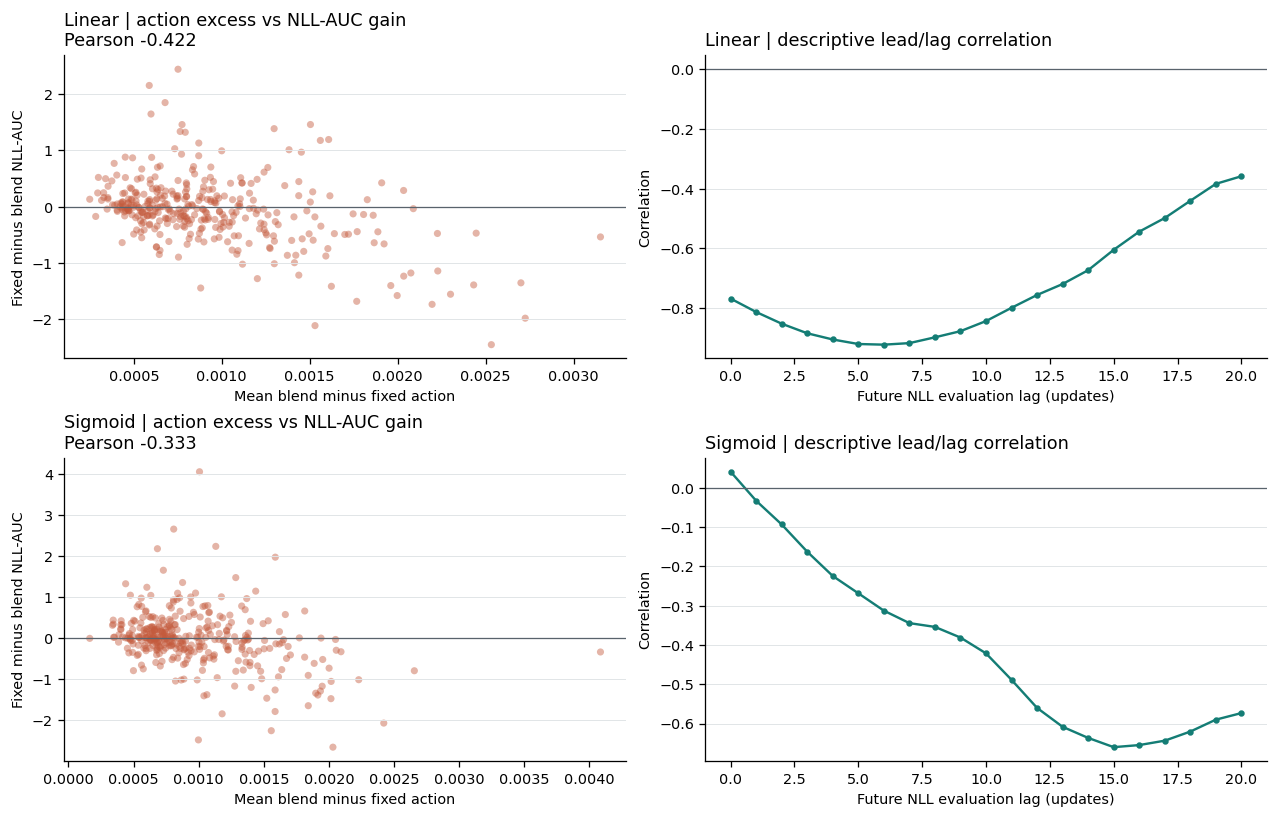

In [7]:
leg_rows = []
for schedule, result in audit['schedules'].items():
    for leg in result['legs']:
        leg_rows.append({'schedule': schedule, 'leg': leg['leg'], 'NLL gain': leg['nll_gain']['mean'], 'accuracy gain': leg['accuracy_gain']['mean']})
display(pd.DataFrame(leg_rows).set_index(['schedule', 'leg']).style.format('{:+.5f}').set_caption('Exploratory per-leg means'))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), layout='constrained')
for row_index, (schedule, result) in enumerate(audit['schedules'].items()):
    replicas = pd.DataFrame(result['replica_rows'])
    axes[row_index, 0].scatter(replicas['mean_action_excess'], replicas['nll_gain'], s=20, alpha=.45, color=colors['blend'], edgecolors='none')
    axes[row_index, 0].axhline(0, color='#59636c', lw=.8)
    axes[row_index, 0].set_title(f"{schedule.capitalize()} | action excess vs NLL-AUC gain\nPearson {result['heterogeneity']['action_vs_terminal_pearson']:+.3f}", loc='left')
    axes[row_index, 0].set_xlabel('Mean blend minus fixed action')
    axes[row_index, 0].set_ylabel('Fixed minus blend NLL-AUC')
    lag = pd.DataFrame(result['lag_correlations'])
    axes[row_index, 1].plot(lag['lag_updates'], lag['correlation'], marker='o', ms=3, color=colors['gain'])
    axes[row_index, 1].axhline(0, color='#59636c', lw=.8)
    axes[row_index, 1].set_title(f'{schedule.capitalize()} | descriptive lead/lag correlation', loc='left')
    axes[row_index, 1].set_xlabel('Future NLL evaluation lag (updates)')
    axes[row_index, 1].set_ylabel('Correlation')
    for ax in axes[row_index]:
        ax.grid(axis='y', color='#e0e4e7', lw=.6)
        ax.spines[['top', 'right']].set_visible(False)
plt.show()

## Numerical pairing audit

Cold-start actions were identical, but policy-specific Lanczos seeds broke parameter equality before treatment actions separated. This is a variance-inflating pairing defect, not evidence for either policy.

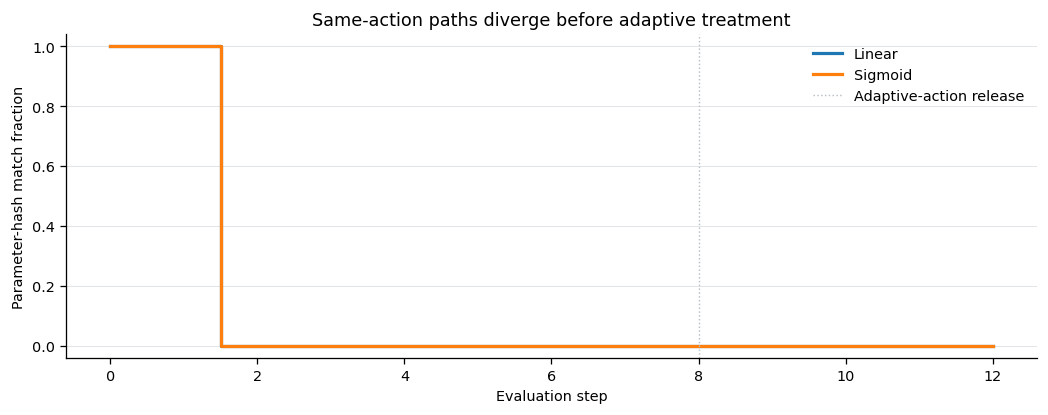

,same-action cold-start pairs,matching Lanczos seeds,first parameter divergence step,cold NLL-AUC SD,cold vs post Pearson
schedule,,,,,
linear,352/352,0/41888,2,0.1208,+0.088
sigmoid,352/352,0/41888,2,0.1334,+0.049


In [8]:
pairing_rows = []
fig, ax = plt.subplots(figsize=(9, 3.5), layout='constrained')
for schedule, result in audit['schedules'].items():
    pairing = result['numerical_pairing']
    pairing_rows.append({
        'schedule': schedule,
        'same-action cold-start pairs': f"{pairing['same_action_cold_start_pairs']}/{pairing['planned_pairs']}",
        'matching Lanczos seeds': f"{pairing['lanczos_seed_matches']}/{pairing['lanczos_seed_comparisons']}",
        'first parameter divergence step': pairing['first_parameter_divergence_step'],
        'cold NLL-AUC SD': pairing['cold_start_nll_auc_gain']['standard_deviation'],
        'cold vs post Pearson': result['heterogeneity']['cold_vs_post_pearson'],
    })
    match = np.asarray(pairing['parameter_hash_match_fraction'])
    ax.step(range(13), match[:13], where='mid', lw=2, label=schedule.capitalize())
ax.axvline(8, color='#b7bec4', lw=.9, ls=':', label='Adaptive-action release')
ax.set(xlabel='Evaluation step', ylabel='Parameter-hash match fraction', ylim=(-.04, 1.04), title='Same-action paths diverge before adaptive treatment')
ax.grid(axis='y', color='#e0e4e7', lw=.6)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.show()
display(pd.DataFrame(pairing_rows).set_index('schedule').style.format({'cold NLL-AUC SD': '{:.4f}', 'cold vs post Pearson': '{:+.3f}'}))

## Evidence ranking and prospective discriminator

1. **Selection and winner's curse** best explain the pilot-to-confirmation reversal.
2. **A coupled upward action shift** is descriptively associated with worse linear NLL, but EWC, Fisher refresh, $q_t$, and learner feedback cannot be separated here.
3. **Schedule timing** remains plausible: sigmoid first ascent differs from its later legs, whereas linear is adverse throughout.
4. **Calibration-sensitive non-9 probability changes** describe why NLL moves without a reliable accuracy effect.
5. **Policy-specific Lanczos randomness** demonstrably adds pre-treatment noise but has little association with post-cold outcomes.
6. **Digit-9 or single-class explanations** receive little support and are not promoted.

The smallest causal successor is a fresh paired $2\times2$ intervention that independently fixes or adapts the EWC action and direct-Fisher-refresh action, with common numerical randomness and a predeclared $q_t$ contract. Phase 3A authorizes no such compute. Phase 3B asks a separate suboptimal-anchor question and must not select timing windows, classes, lags, or outcomes from this audit.